<a href="https://colab.research.google.com/github/23likenny/CIC-Challenge-2025-Kenny-Li-University-of-Michigan-Submission/blob/main/week1_pandas_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Week 1 - Pandas Practice**

Here is where you import the libraries necessary to perform the following tasks!

In [1]:
import pandas as pd
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load the Google Forms .csv into a Pandas dataframe.

In [2]:
df = pd.read_csv('/content/MDST Week 1 - Pandas Practice.csv')

Print out the .head() and the datatypes.

In [4]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 11 columns):
 #   Column                                                                                                            Non-Null Count  Dtype 
---  ------                                                                                                            --------------  ----- 
 0   Timestamp                                                                                                         27 non-null     object
 1   What is your name?                                                                                                27 non-null     object
 2   What is your major?                                                                                               27 non-null     object
 3   What year will you graduate?                                                                                      27 non-null     int64 
 4   If you're American, what state are you f

,What year will you graduate?,(Approximately) How many years of coding experience do you have?,How many credits are you taking this semester?,How many roommates do you have?
count,27.000000,27.000000,27.000000,27.000000
mean,2028.074074,1.518519,16.333333,1.740741
std,0.828619,1.340791,1.414214,1.227649
min,2027.000000,0.000000,12.000000,0.000000
25%,2027.000000,1.000000,15.000000,1.000000
50%,2028.000000,1.000000,17.000000,1.000000
75%,2029.000000,2.000000,17.000000,3.000000
max,2029.000000,6.000000,18.000000,5.000000


Change the column names of the dataframe to better reflect the content.

In [6]:
df.columns = ['timestamp', 'name', 'major', 'year_graduate', 'state', 'country_if_not_usa', 'coding_experience_years', 'num_pets', 'credits_taking', 'roommates', 'michigan_football']

Drop the timestamp column (set axis = 1 as second argument)

In [7]:
df.drop(columns=['timestamp'], axis=1)

,name,major,year_graduate,state,country_if_not_usa,coding_experience_years,num_pets,credits_taking,roommates,michigan_football
0,Will McKanna,DS,2028,MI,NaN,1,2,16,2,NaN
1,Charlie Leversha,DS,2027,IL,NaN,0,1,16,1,2
2,Pranjal Mhetre,CS,2029,NJ,NaN,4,0,18,1,2
3,Yuhuan Liu,DS,2028,NaN,China,0,0,18,2,0
4,Ella Kemp,DS,2029,CA,NaN,0,1,16,1,2
5,Alejandro Hernandez,DS,2029,IL,NaN,2,2,17,1,6 or 7
6,Shlok Kinikar,DS,2028,TX,NaN,1,1,15,5,9
7,Abhinav Burri,DS,2028,MI,NaN,3,0,17,2,4
8,Kate Risley,DS,2029,MI,NaN,2,0,17,1,2
9,Avi Dickman,Political Science,2028,WI,NaN,1,0,15,3,8


If necessary, clean the data of any irregular values (e.g. non-numerical number of pets, incorrectly-formatted state info)

In [65]:
df = df.replace("Michigan ", "MI")
df = df.replace("No pets", 0)
df = df.replace('6 or 7', '6')

What are the value counts of each state?

In [20]:
df['state'].value_counts()

,count
state,
MI,10
IL,3
CA,3
NJ,2
TX,1
WI,1
NY,1
OH,1
NH,1


If people left the country column blank, it's filled with an NaN and that means they're American. Fill these NaN values with 'USA'.

In [44]:
df['country_if_not_usa'] = df['country_if_not_usa'].fillna('USA')
df

,timestamp,name,major,year_graduate,state,country_if_not_usa,coding_experience_years,num_pets,credits_taking,roommates,michigan_football
0,2025/08/12 9:48:42 AM AST,Will McKanna,DS,2028,MI,USA,1,2,16,2,NaN
1,2025/09/21 12:51:39 PM AST,Charlie Leversha,DS,2027,IL,USA,0,1,16,1,2
2,2025/09/21 12:51:46 PM AST,Pranjal Mhetre,CS,2029,NJ,USA,4,0,18,1,2
3,2025/09/21 12:51:47 PM AST,Yuhuan Liu,DS,2028,NaN,China,0,0,18,2,0
4,2025/09/21 12:51:53 PM AST,Ella Kemp,DS,2029,CA,USA,0,1,16,1,2
5,2025/09/21 12:51:58 PM AST,Alejandro Hernandez,DS,2029,IL,USA,2,2,17,1,6 or 7
6,2025/09/21 12:52:01 PM AST,Shlok Kinikar,DS,2028,TX,USA,1,1,15,5,9
7,2025/09/21 12:52:01 PM AST,Abhinav Burri,DS,2028,MI,USA,3,0,17,2,4
8,2025/09/21 12:52:03 PM AST,Kate Risley,DS,2029,MI,USA,2,0,17,1,2
9,2025/09/21 12:52:04 PM AST,Avi Dickman,Political Science,2028,WI,USA,1,0,15,3,8


How many Americans are there? How about non-Americans?

In [35]:
usa_counter = 0
non_usa = 0

for index, value in df['country_if_not_usa'].items():
  if value == 'USA':
    usa_counter += 1
  else:
    non_usa += 1
print(f'There are {usa_counter} students from US')
print(f'There are {non_usa} international students')


There are 24 students from US
There are 3 international students


What is the mean graduation year?

In [49]:
df[['year_graduate']].mean()

,0
year_graduate,2028.074074


What is the median number of pets?

In [56]:
print(df['num_pets'].median())

0.0


What is the max and min number of roommates?

In [58]:
print(f'The max number of roommates is {df["roommates"].max()}')
print(f'The min number of roommates is {df["roommates"].min()}')

The max number of roommates is 5
The min number of roommates is 0


Find the 5 members who have attended the greatest amount of Michigan Football Games. Hint: use .sort_values()

In [68]:
df['michigan_football'] = df['michigan_football'].fillna(0)
df['michigan_football'] = pd.to_numeric(df['michigan_football'])
df['michigan_football'].sort_values(ascending=False).head(5)

,michigan_football
23,20
24,14
16,12
26,9
6,9


Now find the 5 members who have attended the least Michigan Football Games.

In [69]:
df['michigan_football'].sort_values(ascending=True).head(5)

,michigan_football
0,0
3,0
14,0
11,0
20,0


What is the percentage of people who have 1 pet compared to the entire population?

In [76]:
df['num_pets'].value_counts()

print(7 / df['num_pets'].count())

0.25925925925925924


What is the correlation between number of roommates and graduation year?

In [82]:
df['roommates'].corr(df['year_graduate'])

np.float64(-0.5097239391519619)

Graph the number of people we have from each state using seaborn (Hint: create a bar chart/histogram)

<Axes: xlabel='state'>

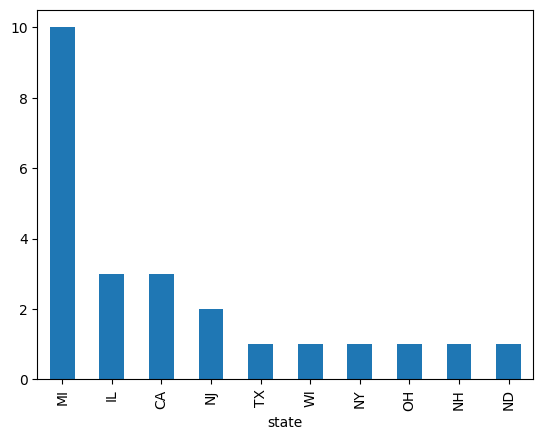

In [81]:
df['state'].value_counts().plot(kind='bar')

When you're done, help the other people around you :)

#***Extra Exercises***

Congratulations on powering through your first work session as a member of the Fall 2025 Michigan Data Science Team!!

Now that you've had some hands-on experience manipulating and exploring structured data (which we conveniently gave to you in a tidy .csv file), it's time to bring those skills to some unstructured data.

Provided below is a list of people and some of their attributes. Using this information and the Pandas Cheat Sheet, create a structured dataframe containing each person and their features. After you do this, research the same questions we looked at for the Criminal Risk Assessment team member data, as well as any other questions that may interest you.

***NOTE:*** If you don't want to type out all of the columns, focus on a handful of attributes that are most interesting to you (i.e. year, coding experience, coffee consumption)

**Happy coding!!**

1. Name: Robert, Sex: Male, Major: DS, Year: 2029, State: N/A, Country: Canada, Coding Experience: 2, Pets: 2, Credits: 18, Roommates: 3, Games Attended: 53, Cups of Coffee Drank Today: 0

2. Name: Prasana, Sex: Female, Major: Information Analysis, Year: 2026, State: Colorado, Country: N/A, Coding Experience: 8, Pets: 0, Credits: 14, Roommates: 1, Games Attended: 3, Cups of Coffee Drank Today: 6

3. Name: Theodore, Sex: Male, Major: CS, Year: 2027, State: Michigan, Country: N/A, Coding Experience: 0, Pets: 0, Credits: 17, Roommates: 2, Games Attended: 0, Cups of Coffee Drank Today: 1

4. Name: Andrea, Sex: Female, Major: DS, Year: 2029, State: Michigan, Country: N/A, Coding Experience: 2, Pets: 3, Credits: 15, Roommates: 2, Games Attended: 4, Cups of Coffee Drank Today: 1

5. Name: Andrea, Sex: Female, Major: DS, Year: 2027, State: Michigan, Country: N/A, Coding Experience: 1, Pets: 6, Credits: 15, Roommates: 1, Games Attended: 3, Cups of Coffee Drank Today: 0

6. Name: Maya, Sex: Female, Major: CS, Year: 2028, State: California, Country: N/A, Coding Experience: 5, Pets: 1, Credits: 16, Roommates: 2, Games Attended: 12, Cups of Coffee Drank Today: 3

7. Name: Daniel, Sex: Male, Major: Information Analysis, Year: 2027, State: N/A, Country: India, Coding Experience: 7, Pets: 0, Credits: 15, Roommates: 1, Games Attended: 6, Cups of Coffee Drank Today: 2

8. Name: Sofia, Sex: Female, Major: DS, Year: 2026, State: Texas, Country: N/A, Coding Experience: 3, Pets: 2, Credits: 18, Roommates: 3, Games Attended: 25, Cups of Coffee Drank Today: 1

9. Name: Liam, Sex: Male, Major: CS, Year: 2029, State: Illinois, Country: N/A, Coding Experience: 1, Pets: 0, Credits: 12, Roommates: 4, Games Attended: 2, Cups of Coffee Drank Today: 4

10. Name: Aisha, Sex: Female, Major: Information Analysis, Year: 2028, State: N/A, Country: UAE, Coding Experience: 6, Pets: 1, Credits: 17, Roommates: 2, Games Attended: 9, Cups of Coffee Drank Today: 0

11. Name: Ethan, Sex: Male, Major: DS, Year: 2027, State: Ohio, Country: N/A, Coding Experience: 4, Pets: 1, Credits: 16, Roommates: 2, Games Attended: 7, Cups of Coffee Drank Today: 2

12. Name: Clara, Sex: Female, Major: CS, Year: 2028, State: N/A, Country: Germany, Coding Experience: 3, Pets: 0, Credits: 18, Roommates: 1, Games Attended: 11, Cups of Coffee Drank Today: 1

13. Name: Mateo, Sex: Male, Major: Information Analysis, Year: 2026, State: Florida, Country: N/A, Coding Experience: 6, Pets: 2, Credits: 14, Roommates: 3, Games Attended: 18, Cups of Coffee Drank Today: 5

14. Name: Yuna, Sex: Female, Major: DS, Year: 2029, State: N/A, Country: South Korea, Coding Experience: 2, Pets: 0, Credits: 13, Roommates: 2, Games Attended: 1, Cups of Coffee Drank Today: 0

15. Name: Marcus, Sex: Male, Major: CS, Year: 2028, State: New York, Country: N/A, Coding Experience: 8, Pets: 1, Credits: 17, Roommates: 2, Games Attended: 22, Cups of Coffee Drank Today: 3